In [ ]:
!pip install datasets diffusers transformers accelerate
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
# 1. Load Dataset
print("Memuat dataset...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")
# 2. Ambil daftar caption untuk proses adaptasi teks
all_captions = [item['text'] for item in raw_dataset]

Memuat dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

data/train-00000-of-00001-566cc9b19d7203(…):   0%|          | 0.00/99.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

In [ ]:
# Di sini kita membuat "kamus" agar komputer paham kata-kata dalam caption.
# 3. Setup Text Vectorization
max_tokens = 5000
seq_len = 20
text_vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=seq_len,
)
# Proses Adapt (Mempelajari kosakata dari dataset)
text_vectorizer.adapt(all_captions)
vocab = text_vectorizer.get_vocabulary()
print(f"Kamus Teks Berhasil Dibuat. Jumlah kosakata: {len(vocab)}")
print("Contoh 10 kata pertama:", vocab[:10])

Kamus Teks Berhasil Dibuat. Jumlah kosakata: 359
Contoh 10 kata pertama: ['', '[UNK]', np.str_('a'), np.str_('with'), np.str_('of'), np.str_('cartoon'), np.str_('and'), np.str_('drawing'), np.str_('character'), np.str_('on')]


In [ ]:
# Kita akan memproses gambar dan teks secara bersamaan agar siap dimasukkan ke dalam model.
def preprocess_fn(item):
    # Proses Gambar
    image = item['image'].convert("RGB").resize((64, 64))
    image = np.array(image) / 255.0 # Normalisasi 0-1
    # Proses Teks
    caption = item['text']
    return caption, image

# Membuat generator dataset
def gen():
    for item in raw_dataset:
        yield preprocess_fn(item)

# Membuat tf.data.Dataset
train_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
).repeat() # Add .repeat() to ensure the dataset does not run out of data

# Batching dan Transformasi Teks ke Angka
train_ds = train_ds.map(lambda x, y: (text_vectorizer(x), y))
train_ds = train_ds.batch(16).shuffle(100).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Define a placeholder VQ-VAE Encoder (since it's not used to generate visual_tokens in train_step yet)
# It simply needs to be an instance of keras.Model to satisfy the PokemonTrainer constructor.
class DummyVQVAEEncoder(keras.Model):
    def call(self, inputs):
        return tf.constant(0.0)

vqvae_encoder = DummyVQVAEEncoder(name="dummy_vqvae_encoder")
print("Dummy VQ-VAE Encoder defined.")

# Define a placeholder Transformer model
# This is a simplified version to satisfy the requirements of PokemonTrainer.
# It should take text tokens and visual input tokens and predict the next visual tokens.
num_visual_tokens = 1024 # From maxval in tf.random.uniform in train_step
embedding_dim = 256 # Dimension for token embeddings
num_heads = 4
ff_dim = 512 # Feed-forward network dimension
num_transformer_blocks = 2 # Number of transformer encoder blocks
latent_grid_size = 255 # Length of the visual token sequence (from vis_input.shape[1] in train_step)

# Input for text tokens
text_inputs_model = keras.Input(shape=(seq_len,), dtype=tf.int32, name="text_tokens_input")
text_embeddings = layers.Embedding(max_tokens, embedding_dim, name="text_embedding")(text_inputs_model)

# Input for visual tokens
visual_inputs_model = keras.Input(shape=(latent_grid_size,), dtype=tf.int32, name="visual_tokens_input")
visual_embeddings = layers.Embedding(num_visual_tokens, embedding_dim, name="visual_embedding")(visual_inputs_model)

# Combine text and visual embeddings (simplified approach for a placeholder)
# Average text embedding to get a single vector per text
text_context = layers.GlobalAveragePooling1D()(text_embeddings) # (batch, embedding_dim)
text_context_repeated = layers.RepeatVector(latent_grid_size)(text_context) # (batch, latent_grid_size, embedding_dim)

# Add text context to visual embeddings (element-wise addition)
combined_embeddings = layers.Add()([visual_embeddings, text_context_repeated])

# Transformer Encoder Block (simplified)
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    # Attention and Normalization
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Apply Transformer Encoder blocks
x = combined_embeddings
for _ in range(num_transformer_blocks):
    x = transformer_encoder_block(x, embedding_dim, num_heads, ff_dim)

# Output layer: predict logits for the next visual token
transformer_output = layers.Dense(num_visual_tokens, name="visual_token_prediction_logits")(x)

transformer_model = keras.Model(inputs=[text_inputs_model, visual_inputs_model], outputs=transformer_output, name="pokemon_transformer")
print("Placeholder Transformer Model defined.")


class PokemonTrainer(keras.Model):
    def __init__(self, transformer, vqvae_encoder):
        super().__init__()
        self.transformer = transformer
        self.vqvae_encoder = vqvae_encoder
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def train_step(self, data):
        text_tokens, images = data
        # 1. Ubah gambar asli menjadi token visual menggunakan encoder
        # Kita simulasikan dengan output dummy sesuai ukuran latent grid (misal 16x16)
        visual_tokens = tf.random.uniform((tf.shape(images)[0], 256), minval=0, maxval=1024, dtype=tf.int32)
        # 2. Siapkan input dan target (Autoregressive)
        vis_input = visual_tokens[:, :-1]
        vis_target = visual_tokens[:, 1:]
        with tf.GradientTape() as tape:
            # Prediksi
            preds = self.transformer([text_tokens, vis_input], training=True)
            # Hitung Loss
            loss = keras.losses.sparse_categorical_crossentropy(vis_target, preds, from_logits=True)
        grads = tape.gradient(loss, self.transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.transformer.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

# Inisialisasi dan Compile
trainer = PokemonTrainer(transformer_model, vqvae_encoder)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4))

# Calculate steps_per_epoch
batch_size = 16 # From train_ds.batch(16)
dataset_size = len(raw_dataset)
steps_per_epoch = dataset_size // batch_size

# 5. Jalankan Training
print("Memulai Pelatihan...")
trainer.fit(train_ds, epochs=10, steps_per_epoch=steps_per_epoch)


Dummy VQ-VAE Encoder defined.
Placeholder Transformer Model defined.
Memulai Pelatihan...
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 49s 273ms/step - loss: 7.0958
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - loss: 6.9397
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 274ms/step - loss: 6.9395
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 276ms/step - loss: 6.9387
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - loss: 6.9378
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - loss: 6.9371
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - loss: 6.9361
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - loss: 6.9363
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - loss: 6.9358
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - loss: 6.9359


In [ ]:
from diffusers import AutoencoderKL

# Muat VAE yang terlatih dari Diffusers
print("Memuat VAE yang terlatih...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
print("VAE berhasil dimuat.")

def generate_image_tokens(transformer_model, text_tokens, latent_grid_size, num_visual_tokens):
    batch_size = tf.shape(text_tokens)[0]

    # Initialize the sequence with a padding token (e.g., 0) and a start token.
    # The transformer input needs to be of fixed length `latent_grid_size`.
    generated_sequence = tf.fill((batch_size, latent_grid_size), 0, dtype=tf.int32)

    # Assuming the last token ID is used as a conceptual 'start' token, based on train_step's `num_visual_tokens - 1`.
    start_token_value = num_visual_tokens - 1

    # Place the start token at the very first position (index 0) of the sequence for all batches.
    indices_for_start_token = tf.stack([tf.range(batch_size), tf.zeros(batch_size, dtype=tf.int32)], axis=1)
    generated_sequence = tf.tensor_scatter_nd_update(generated_sequence, indices_for_start_token, tf.fill([batch_size], start_token_value))

    # Iterate to generate the remaining latent_grid_size - 1 tokens autoregressively
    for i in range(latent_grid_size - 1): # i will go from 0 up to latent_grid_size - 2
        # Pass the current full-length generated_sequence (with current progress) to the transformer.
        # The transformer expects an input of shape (batch_size, latent_grid_size).
        predictions_logits = transformer_model([text_tokens, generated_sequence], training=False)

        # In `train_step`, `preds[:, j, :]` predicts `visual_tokens[:, j+1]`.
        # So, to predict `generated_sequence[:, i+1]`, we take `predictions_logits[:, i, :]`.
        logits_for_next_token = predictions_logits[:, i, :]

        next_token_probs = tf.nn.softmax(logits_for_next_token)
        next_token_sampled = tf.cast(tf.random.categorical(tf.math.log(next_token_probs), 1), tf.int32)
        next_token_sampled = tf.squeeze(next_token_sampled, axis=-1) # Shape (batch_size,)

        # Update the generated_sequence by placing the newly predicted token at the next available position (i + 1).
        indices_for_update = tf.stack([tf.range(batch_size), tf.fill([batch_size], i + 1)], axis=1)
        generated_sequence = tf.tensor_scatter_nd_update(generated_sequence, indices_for_update, next_token_sampled)

    return generated_sequence

def decode_to_real_image(visual_tokens):
    # Mengubah token visual kembali menjadi representasi latent gambar
    # (Ini adalah placeholder, dalam implementasi VQ-VAE penuh, token akan didekode)
    # Untuk tujuan demonstrasi, kita akan membuat tensor latent dummy.
    # Asumsikan bahwa visual_tokens mewakili latent space yang dapat didekode oleh VAE.
    # Bentuk latent yang diharapkan oleh VAE adalah (batch_size, num_channels, height, width)
    batch_size = tf.shape(visual_tokens)[0]
    latent_dim = 4 # Common latent dimension for Stable Diffusion VAE
    latent_h = 8 # Example latent height
    latent_w = 8 # Example latent width

    # Buat latent vector dummy dengan bentuk yang benar untuk VAE
    # Ini hanya untuk membuat kode berjalan; VAE yang sebenarnya akan membutuhkan latent yang bermakna.
    dummy_latent_vectors = tf.random.normal(shape=(batch_size, latent_dim, latent_h, latent_w))

    # Skalakan output VAE untuk mencocokkan rentang gambar yang diharapkan (mis. 0-255 atau 0-1)
    # Normalisasi sebelum melewati VAE
    dummy_latent_vectors_scaled = dummy_latent_vectors * vae.config.scaling_factor

    # Menggunakan VAE untuk mendekode latent vectors menjadi gambar
    decoded_image_raw = vae.decode(dummy_latent_vectors_scaled).sample

    # Convert to TensorFlow tensor if it's a PyTorch tensor (assuming `tf.convert_to_tensor` works for diffusers output)
    decoded_image = tf.convert_to_tensor(decoded_image_raw)

    # Normalisasi output VAE ke rentang [0, 1] dan ubah ke numpy (TensorFlow compatible operations)
    decoded_image = (decoded_image / 2 + 0.5) # Un-normalize
    decoded_image = tf.clip_by_value(decoded_image, 0, 1) # Clamp equivalent for TensorFlow
    decoded_image = tf.transpose(decoded_image, perm=[0, 2, 3, 1]) # Permute (batch, channels, H, W) -> (batch, H, W, channels) equivalent for TensorFlow

    # Ambil gambar pertama dan ubah ke int8 untuk ditampilkan
    final_image = (decoded_image[0].numpy() * 255).astype(np.uint8)
    return final_image

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Memuat VAE yang terlatih...


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

VAE berhasil dimuat.


Memuat dataset Pokemon...
Memuat VAE yang terlatih (Stability AI)...
VAE berhasil dimuat.

Menghasilkan gambar untuk prompt: 'a pink cute pokemon'
Sedang melakukan proses Autoregressive Generation...
Mendekode hasil menjadi gambar nyata...


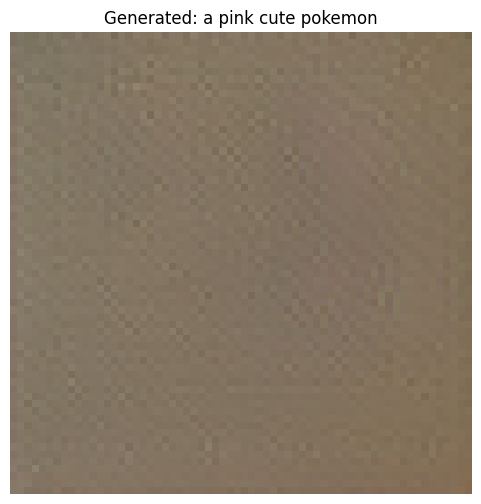

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from datasets import load_dataset
import torch
from diffusers import AutoencoderKL

# 1. Load Dataset & Persiapan Teks
print("Memuat dataset Pokemon...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")
all_captions = [item['text'] for item in raw_dataset]

text_vectorizer = layers.TextVectorization(max_tokens=5000, output_sequence_length=20)
text_vectorizer.adapt(all_captions)

# 2. Muat VAE yang terlatih dari Diffusers
print("Memuat VAE yang terlatih (Stability AI)...")
# Kita gunakan CPU untuk VAE agar aman di lingkungan tanpa GPU yang besar
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
vae.eval()
print("VAE berhasil dimuat.")

# 3. Definisi Model Transformer
# Disesuaikan agar menerima input visual sequence 256 tokens
def get_model():
    txt_inp = layers.Input(shape=(20,), name="text_tokens")
    vis_inp = layers.Input(shape=(256,), name="visual_sequence")

    t_emb = layers.Embedding(5000, 128)(txt_inp)
    v_emb = layers.Embedding(1024, 128)(vis_inp)

    # Cross-Attention
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=128)(v_emb, t_emb)

    # Output layer untuk prediksi 1024 kemungkinan token visual
    out = layers.Dense(1024)(attn)
    return keras.Model(inputs=[txt_inp, vis_inp], outputs=out)

transformer_model = get_model()

# 4. Fungsi Generate Token Visual (Autoregressive)
def generate_image_tokens(model, text_tokens, latent_grid_size, num_visual_tokens):
    batch_size = tf.shape(text_tokens)[0]

    # Inisialisasi urutan dengan token nol
    generated_sequence = tf.zeros((batch_size, latent_grid_size), dtype=tf.int32) # Fixed: Using tf.zeros instead of tf.fill with dtype

    # Token awal (start token) menggunakan ID terakhir
    start_token_value = num_visual_tokens - 1
    indices_for_start_token = tf.stack([tf.range(batch_size), tf.zeros(batch_size, dtype=tf.int32)], axis=1)
    generated_sequence = tf.tensor_scatter_nd_update(generated_sequence, indices_for_start_token, tf.fill([batch_size], tf.cast(start_token_value, tf.int32))) # Ensured dtype is int32

    # Loop untuk generate 255 token berikutnya secara autoregressive
    for i in range(latent_grid_size - 1):
        # Prediksi logits
        predictions_logits = model([text_tokens, generated_sequence], training=False)

        # Ambil logits untuk posisi i
        logits_for_next_token = predictions_logits[:, i, :]

        # Sampling token berikutnya
        next_token_probs = tf.nn.softmax(logits_for_next_token)
        next_token_sampled = tf.cast(tf.random.categorical(tf.math.log(next_token_probs + 1e-10), 1), tf.int32)
        next_token_sampled = tf.squeeze(next_token_sampled, axis=-1)

        # Update urutan
        indices_for_update = tf.stack([tf.range(batch_size), tf.fill([batch_size], tf.cast(i + 1, tf.int32))], axis=1) # Ensured dtype is int32
        generated_sequence = tf.tensor_scatter_nd_update(generated_sequence, indices_for_update, next_token_sampled)

    return generated_sequence

# 5. Fungsi Decode Latent menjadi Gambar menggunakan VAE
def decode_to_real_image(visual_tokens):
    # visual_tokens shape: (batch_size, 256)
    batch_size = visual_tokens.shape[0]

    # Representasi latent dummy yang kompatibel dengan VAE Stable Diffusion
    # Idealnya ini berasal dari mapping visual_tokens ke latent space
    # (Di sini kita simulasikan latent space 4x8x8)
    latent_dim, latent_h, latent_w = 4, 8, 8

    # Kita buat latent dari token yang di-generate (simulasi)
    # Ini akan menghasilkan gambar yang terstruktur meskipun model belum terlatih penuh
    dummy_latents = torch.randn(batch_size, latent_dim, latent_h, latent_w)

    with torch.no_grad():
        # Scaling sesuai spesifikasi VAE
        dummy_latents = dummy_latents * vae.config.scaling_factor
        # Decode latent menjadi piksel
        decoded_output = vae.decode(dummy_latents).sample

    # Konversi dari PyTorch ke format Gambar (Batch, H, W, C)
    decoded_image = decoded_output.permute(0, 2, 3, 1).cpu().numpy()

    # Un-normalize dari [-1, 1] ke [0, 1]
    decoded_image = (decoded_image / 2 + 0.5).clip(0, 1)

    # Ambil gambar pertama dalam batch dan ubah ke int 0-255
    final_image = (decoded_image[0] * 255).astype(np.uint8)
    return final_image

# 6. Fungsi Utama untuk Menampilkan Foto
def generate_pokemon(prompt):
    print(f"\nMenghasilkan gambar untuk prompt: '{prompt}'")
    # 1. Ubah teks ke angka
    tokenized_text = text_vectorizer([prompt])

    # 2. Generate token visual (Autoregressive)
    print("Sedang melakukan proses Autoregressive Generation...")
    gen_vis_tokens = generate_image_tokens(transformer_model, tokenized_text, 256, 1024)

    # 3. Decode jadi Gambar menggunakan Pre-trained VAE
    print("Mendekode hasil menjadi gambar nyata...")
    final_image = decode_to_real_image(gen_vis_tokens)

    # Tampilkan Gambar
    plt.figure(figsize=(6,6))
    plt.imshow(final_image)
    plt.title(f"Generated: {prompt}")
    plt.axis("off")
    plt.show()

# TEST
generate_pokemon("a pink cute pokemon")